# 26 - LSEG/Gemma sparse risk brakes

**Question.** Can the expanded Reuters/Gemma sample provide an independent,
non-pooled check of the downside-risk mechanism found on FNSPID, or a
turnover-conscious improvement to a long 44-company basket?

This is an **iterative, retrospective LSEG analysis**. Notebook 13 already
opened these returns and selected Gemma `strongest_event` as the best gross
cross-sectional arm. The result cannot be a new holdout alpha claim.

Two rules are frozen before the return cells below:

1. **Unchanged market hysteresis.** Headline-weighted Gemma negative share is
   z-scored against the prior 252 sessions (minimum 126); enter risk-off at
   1.5, exit at 0.5, and hold 25% of the basket. This is exactly the rule used
   for FNSPID, with no shortened warm-up.
2. **Sparse firm brake.** Hold a fixed-share, initially equal-dollar basket.
   For one open-to-open interval, cut a company's fixed shares to 25% only
   when its mapped Gemma `strongest_event` equals the maximally negative
   score, -1.0. Cash earns zero. This threshold is semantic, not return-fit.

Both arms use the existing 15-minute information buffer, split-adjusted
non-dividend-adjusted opens, 10 bps per traded side, and final liquidation.
The market rule requires at least 60 post-warm-up sessions and five risk-off
sessions to be considered feasible. The firm rule requires 126 sessions,
both temporal halves at least 60 sessions, and at least 25 distinct entries.

In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "final_experiments").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    build_market_negative_pressure,
    build_market_risk_exposure,
    paired_block_bootstrap_difference,
)

SEED = 20260805
TRADING_SESSIONS = 252
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
RISK_FRACTION = 0.25
BLOCK_LENGTH = 5
BOOTSTRAP_REPLICATIONS = 4_999
MIN_FIRM_SESSIONS = 126
MIN_HALF_SESSIONS = 60
MIN_FIRM_ENTRIES = 25
MIN_MARKET_Z_SESSIONS = 60
MIN_MARKET_RISK_OFF = 5

GEMMA_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv",
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/26_lseg_gemma_sparse_risk_brakes"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()

## Accounting helper

The basket is self-financing in cash and fixed shares. At each entry open,
it trades from yesterday's holdings to the pre-declared target shares, pays
costs on absolute traded notional, then earns the move to the next complete
44-company open. The final interval includes liquidation. This avoids
pretending that a daily equal-weight portfolio has zero rebalance turnover.

In [2]:
def fixed_share_targets(
    open_wide: pd.DataFrame,
    sessions: pd.DatetimeIndex,
    modifiers: pd.DataFrame,
    *,
    entry_cost_bps: float = 0.0,
) -> pd.DataFrame:
    """Build equal-dollar fixed shares, reserving cash for initial costs."""
    sessions = pd.DatetimeIndex(sessions)
    symbols = open_wide.columns
    use = modifiers.reindex(index=sessions, columns=symbols)
    if use.isna().any().any():
        raise ValueError("modifiers must be complete on every session and symbol")
    if not use.ge(0).all().all() or not use.le(1).all().all():
        raise ValueError("modifiers must lie in [0, 1]")
    if entry_cost_bps < 0:
        raise ValueError("entry_cost_bps must be non-negative")
    first_open = open_wide.loc[sessions[0], symbols]
    funded_notional = 1.0 / (1.0 + entry_cost_bps / 10_000.0)
    base_shares = (funded_notional / len(symbols)) / first_open
    return use.mul(base_shares, axis="columns")


def simulate_fixed_share_targets(
    open_wide: pd.DataFrame,
    targets: pd.DataFrame,
    *,
    cost_bps_per_side: float,
) -> pd.DataFrame:
    """Simulate fixed-share target holdings and liquidate after the last interval."""
    if cost_bps_per_side < 0:
        raise ValueError("cost_bps_per_side must be non-negative")
    sessions = pd.DatetimeIndex(targets.index)
    symbols = list(targets.columns)
    calendar = pd.DatetimeIndex(open_wide.index)
    locations = calendar.get_indexer(sessions)
    if (locations < 0).any() or (locations + 1 >= len(calendar)).any():
        raise ValueError("every target session must have a next complete price session")
    if len(sessions) > 1 and not np.array_equal(locations[1:], locations[:-1] + 1):
        raise ValueError("target sessions must be consecutive complete price sessions")

    rate = cost_bps_per_side / 10_000.0
    cash = 1.0
    holdings = np.zeros(len(symbols), dtype=float)
    rows: list[dict[str, float | int | pd.Timestamp]] = []
    for offset, (session, location) in enumerate(zip(sessions, locations, strict=True)):
        start_price = open_wide.loc[session, symbols].to_numpy(dtype=float)
        end_session = calendar[location + 1]
        end_price = open_wide.loc[end_session, symbols].to_numpy(dtype=float)
        wealth_start = float(cash + np.dot(holdings, start_price))
        target = targets.loc[session, symbols].to_numpy(dtype=float)
        delta = target - holdings
        traded_notional = float(np.abs(delta * start_price).sum())
        entry_cost = rate * traded_notional
        cash -= float(np.dot(delta, start_price)) + entry_cost
        holdings = target
        post_trade_wealth = float(cash + np.dot(holdings, start_price))
        exposure = float(np.abs(holdings * start_price).sum() / post_trade_wealth)

        liquidation_notional = 0.0
        liquidation_cost = 0.0
        if offset == len(sessions) - 1:
            liquidation_notional = float(np.abs(holdings * end_price).sum())
            liquidation_cost = rate * liquidation_notional
            cash += float(np.dot(holdings, end_price)) - liquidation_cost
            holdings = np.zeros(len(symbols), dtype=float)
            wealth_end = float(cash)
        else:
            wealth_end = float(cash + np.dot(holdings, end_price))

        total_traded = traded_notional + liquidation_notional
        total_cost = entry_cost + liquidation_cost
        rows.append(
            {
                "session_date": session,
                "return_end_date": end_session,
                "net_return": wealth_end / wealth_start - 1.0,
                "wealth_start": wealth_start,
                "wealth_end": wealth_end,
                "turnover": total_traded / wealth_start,
                "cost_return": total_cost / wealth_start,
                "gross_exposure": exposure,
                "active_positions": int(np.sum(np.abs(target) > 1e-15)),
            }
        )
    return pd.DataFrame(rows)


def evaluate_targets(
    open_wide: pd.DataFrame,
    targets: pd.DataFrame,
    *,
    cost_bps_per_side: float,
) -> pd.DataFrame:
    gross = simulate_fixed_share_targets(open_wide, targets, cost_bps_per_side=0.0)
    net = simulate_fixed_share_targets(
        open_wide,
        targets,
        cost_bps_per_side=cost_bps_per_side,
    )
    out = net.copy()
    out["gross_return"] = gross["net_return"].to_numpy()
    out["downside_sq"] = np.minimum(out["net_return"], 0.0) ** 2
    return out


def path_summary(daily: pd.DataFrame) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    gross_equity = np.cumprod(1.0 + gross)
    net_equity = np.cumprod(1.0 + net)
    net_peak = np.maximum.accumulate(np.r_[1.0, net_equity])
    net_with_start = np.r_[1.0, net_equity]

    def sharpe(values: np.ndarray) -> float:
        std = float(np.std(values, ddof=1))
        return float(math.sqrt(TRADING_SESSIONS) * np.mean(values) / std) if std > 0 else np.nan

    return {
        "n_sessions": int(len(daily)),
        "mean_gross_bps_day": float(np.mean(gross) * 10_000),
        "mean_net_bps_day": float(np.mean(net) * 10_000),
        "sharpe_gross": sharpe(gross),
        "sharpe_net": sharpe(net),
        "ann_vol_net": float(np.std(net, ddof=1) * math.sqrt(TRADING_SESSIONS)),
        "total_return_gross": float(gross_equity[-1] - 1.0),
        "total_return_net": float(net_equity[-1] - 1.0),
        "max_drawdown": float(np.min(net_with_start / net_peak - 1.0)),
        "mean_turnover": float(daily["turnover"].mean()),
        "total_turnover": float(daily["turnover"].sum()),
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
    }


# Deterministic accounting checks before loading research returns.
toy_prices = pd.DataFrame(
    [[1.0, 1.0], [1.0, 2.0]],
    index=pd.to_datetime(["2026-01-02", "2026-01-05"]),
    columns=["A", "B"],
)
toy_modifiers = pd.DataFrame(1.0, index=toy_prices.index[:1], columns=toy_prices.columns)
toy_targets = fixed_share_targets(toy_prices, toy_prices.index[:1], toy_modifiers)
toy = simulate_fixed_share_targets(toy_prices, toy_targets, cost_bps_per_side=0.0)
assert np.isclose(toy.loc[0, "net_return"], 0.5)
toy_cost = simulate_fixed_share_targets(toy_prices, toy_targets, cost_bps_per_side=10.0)
assert toy_cost.loc[0, "net_return"] < toy.loc[0, "net_return"]
print("fixed-share accounting checks passed")

fixed-share accounting checks passed


## Data and causal coverage audit

Only aggregate firm-open sentiment is loaded; no licensed headline text is
printed. Each session must contain all 44 companies and every applied signal
must have a next complete 44-company price open.

In [3]:
gemma = pd.read_parquet(GEMMA_PATH)
gemma["session_date"] = pd.to_datetime(gemma["session_date"]).dt.normalize()
prices = pd.concat(
    [pd.read_csv(path, parse_dates=["session_date"]) for path in PRICE_PATHS],
    ignore_index=True,
)
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
if prices.duplicated(["symbol", "session_date"]).any():
    raise ValueError("duplicate symbol/session price rows")
if gemma.duplicated(["symbol", "session_date"]).any():
    raise ValueError("duplicate symbol/session Gemma rows")

open_wide = (
    prices.pivot(index="session_date", columns="symbol", values="open")
    .sort_index()
    .dropna(axis="index")
)
gemma_sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = sorted(gemma["symbol"].unique())
if len(symbols) != 44 or open_wide.shape[1] != 44:
    raise ValueError("expected the fixed 44-company LSEG population")
if not gemma.groupby("session_date")["symbol"].nunique().eq(44).all():
    raise ValueError("Gemma firm-open panel is not complete by session")
if len(gemma_sessions.difference(open_wide.index)):
    raise ValueError("Gemma sessions missing complete 44-company prices")
calendar_locations = open_wide.index.get_indexer(gemma_sessions)
if not np.array_equal(calendar_locations[1:], calendar_locations[:-1] + 1):
    raise ValueError("Gemma sessions are not consecutive on the complete price calendar")
if calendar_locations[-1] + 1 >= len(open_wide.index):
    raise ValueError("last Gemma session has no next complete price open")

coverage = pd.DataFrame(
    [
        {
            "gemma_firm_open_rows": len(gemma),
            "gemma_sessions": len(gemma_sessions),
            "companies": len(symbols),
            "first_entry_session": gemma_sessions.min(),
            "last_entry_session": gemma_sessions.max(),
            "last_return_end": open_wide.index[calendar_locations[-1] + 1],
            "complete_price_sessions": len(open_wide),
            "repaired_price_rows": int(prices["repaired"].sum()),
        }
    ]
)
display(coverage)

,gemma_firm_open_rows,gemma_sessions,companies,first_entry_session,last_entry_session,last_return_end,complete_price_sessions,repaired_price_rows
0,7348,167,44,2025-10-27,2026-06-26,2026-06-29,175,0


## Signal construction (still before return evaluation)

The sparse firm event is exactly `strongest_event == -1.0`. It is not a
quantile estimated on these returns. The market pressure reuses the exact
lagged normalization and hysteresis from Notebook 20.

In [4]:
strongest = gemma.pivot(index="session_date", columns="symbol", values="strongest_event").reindex(
    index=gemma_sessions,
    columns=symbols,
)
firm_flag = strongest.le(-1.0 + 1e-12)
firm_modifiers = pd.DataFrame(1.0, index=gemma_sessions, columns=symbols)
firm_modifiers = firm_modifiers.mask(firm_flag, RISK_FRACTION)
baseline_modifiers = pd.DataFrame(1.0, index=gemma_sessions, columns=symbols)

pressure = build_market_negative_pressure(
    gemma.rename(columns={"unique_headline_count": "n"}),
    gemma_sessions,
    trailing_window=252,
    min_periods=126,
)
market_exposure = build_market_risk_exposure(
    pressure,
    mode="hysteresis",
    entry_z=1.5,
    exit_z=0.5,
    risk_exposure=RISK_FRACTION,
)
market_eligible = market_exposure.loc[market_exposure["negative_pressure_z"].notna()].copy()
market_sessions = pd.DatetimeIndex(market_eligible["session_date"])
market_modifiers = pd.DataFrame(
    np.repeat(market_eligible["exposure"].to_numpy()[:, None], len(symbols), axis=1),
    index=market_sessions,
    columns=symbols,
)

prior_flag = firm_flag.shift(1, fill_value=False)
firm_entries = firm_flag & ~prior_flag
signal_audit = pd.DataFrame(
    [
        {
            "firm_flagged_rows": int(firm_flag.sum().sum()),
            "firm_flagged_share": float(firm_flag.to_numpy().mean()),
            "firm_entry_events": int(firm_entries.sum().sum()),
            "firm_active_sessions": int(firm_flag.any(axis=1).sum()),
            "median_flagged_names_active_session": float(firm_flag.sum(axis=1).loc[lambda s: s.gt(0)].median()),
            "market_z_sessions": int(market_eligible["negative_pressure_z"].notna().sum()),
            "market_risk_off_sessions": int(market_eligible["risk_off"].sum()),
            "market_risk_off_episodes": int(
                (market_eligible["risk_off"] & ~market_eligible["risk_off"].shift(fill_value=False)).sum()
            ),
        }
    ]
)
display(signal_audit)

,firm_flagged_rows,firm_flagged_share,firm_entry_events,firm_active_sessions,median_flagged_names_active_session,market_z_sessions,market_risk_off_sessions,market_risk_off_episodes
0,143,0.019461,118,99,1.0,41,1,1


## Primary fixed-share backtests

The full firm brake and its two chronological halves are evaluated. The
market arm is reported only on its finite-z tail and cannot be interpreted
unless its pre-declared feasibility gate passes.

In [5]:
full_midpoint = len(gemma_sessions) // 2
periods = {
    "full": gemma_sessions,
    "first_half": gemma_sessions[:full_midpoint],
    "second_half": gemma_sessions[full_midpoint:],
}


def build_period_paths(
    sessions: pd.DatetimeIndex,
    modifiers_by_arm: dict[str, pd.DataFrame],
    *,
    cost_bps: float,
) -> dict[str, pd.DataFrame]:
    paths: dict[str, pd.DataFrame] = {}
    for arm, modifiers in modifiers_by_arm.items():
        target = fixed_share_targets(
            open_wide,
            sessions,
            modifiers.loc[sessions],
            entry_cost_bps=cost_bps,
        )
        paths[arm] = evaluate_targets(
            open_wide,
            target,
            cost_bps_per_side=cost_bps,
        )
    return paths


daily_paths: dict[str, dict[str, pd.DataFrame]] = {}
summary_rows: list[dict[str, float | int | str]] = []
for period, sessions in periods.items():
    daily_paths[period] = build_period_paths(
        sessions,
        {"baseline": baseline_modifiers, "firm_brake": firm_modifiers},
        cost_bps=COST_BPS,
    )
    for arm, daily in daily_paths[period].items():
        summary_rows.append({"period": period, "arm": arm, **path_summary(daily)})

market_paths = build_period_paths(
    market_sessions,
    {
        "market_baseline": pd.DataFrame(1.0, index=market_sessions, columns=symbols),
        "market_hysteresis": market_modifiers,
    },
    cost_bps=COST_BPS,
)
for arm, daily in market_paths.items():
    summary_rows.append({"period": "market_finite_z", "arm": arm, **path_summary(daily)})

results = pd.DataFrame(summary_rows)
display(
    results[
        [
            "period",
            "arm",
            "n_sessions",
            "sharpe_gross",
            "sharpe_net",
            "total_return_net",
            "max_drawdown",
            "mean_turnover",
            "mean_gross_exposure",
        ]
    ]
)

,period,arm,n_sessions,sharpe_gross,sharpe_net,total_return_net,max_drawdown,mean_turnover,mean_gross_exposure
0,full,baseline,167,1.499652,1.471957,0.100101,-0.059252,0.012007,1.000000
1,full,firm_brake,167,1.614350,1.526075,0.102904,-0.058219,0.036057,0.984688
2,first_half,baseline,83,2.708375,2.647852,0.088891,-0.032443,0.024058,1.000000
3,first_half,firm_brake,83,2.765413,2.655738,0.088273,-0.033153,0.043615,0.989271
4,second_half,baseline,84,0.405538,0.345547,0.009883,-0.055669,0.023886,1.000000
5,second_half,firm_brake,84,0.579327,0.446773,0.013112,-0.054758,0.052229,0.979481
6,market_finite_z,market_baseline,41,1.293884,1.157930,0.015416,-0.017524,0.048945,1.000000
7,market_finite_z,market_hysteresis,41,0.894572,0.748731,0.009573,-0.017524,0.048803,0.981712


## Paired inference, cost curve, and stability

The confirmatory-style family has two paired outcomes for the full firm
brake: daily net return and squared downside. The half-sample estimates are
descriptive stability checks. A five-session circular block reflects the
short 167-session sample.

In [6]:
inference_rows: list[dict[str, float | int | str | bool]] = []
for period in periods:
    for outcome_offset, outcome in enumerate(("net_return", "downside_sq")):
        estimate = paired_block_bootstrap_difference(
            daily_paths[period]["firm_brake"],
            daily_paths[period]["baseline"],
            value_col=outcome,
            block_length=BLOCK_LENGTH,
            replications=BOOTSTRAP_REPLICATIONS,
            seed=SEED + outcome_offset + 10 * list(periods).index(period),
        )
        inference_rows.append({"period": period, "outcome": outcome, **estimate})
inference = pd.DataFrame(inference_rows)
inference["bh_reject_q05"] = False
full_index = inference.index[inference["period"].eq("full")]
inference.loc[full_index, "bh_reject_q05"] = benjamini_hochberg(
    inference.loc[full_index, "p_two_sided"].tolist(),
    q=0.05,
)
display(inference)

cost_rows: list[dict[str, float | int | str]] = []
for cost in COST_GRID:
    paths = build_period_paths(
        gemma_sessions,
        {"baseline": baseline_modifiers, "firm_brake": firm_modifiers},
        cost_bps=cost,
    )
    for arm, daily in paths.items():
        cost_rows.append(
            {"arm": arm, "cost_bps_per_side": cost, **path_summary(daily)}
        )
cost_curve = pd.DataFrame(cost_rows)
display(
    cost_curve[
        [
            "arm",
            "cost_bps_per_side",
            "sharpe_net",
            "total_return_net",
            "mean_turnover",
        ]
    ]
)

,period,outcome,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,full,net_return,167,1.478655e-05,-4.049452e-05,6.779529e-05,0.5884,5,4999,20260805,False
1,full,downside_sq,167,-4.675723e-07,-8.179107e-07,-1.293995e-07,0.0088,5,4999,20260806,True
2,first_half,net_return,83,-7.232084e-06,-9.188125e-05,7.016319e-05,0.8544,5,4999,20260815,False
3,first_half,downside_sq,83,-3.798571e-07,-9.326263e-07,1.208632e-07,0.1538,5,4999,20260816,False
4,second_half,net_return,84,3.745874e-05,-2.985120e-05,1.084731e-04,0.2836,5,4999,20260825,False
5,second_half,downside_sq,84,-5.720969e-07,-1.000682e-06,-1.547875e-07,0.0096,5,4999,20260826,False


,arm,cost_bps_per_side,sharpe_net,total_return_net,mean_turnover
0,baseline,0.0,1.499699,0.102304,0.012013
1,firm_brake,0.0,1.614393,0.109390,0.035993
2,baseline,1.0,1.496947,0.102083,0.012013
3,firm_brake,1.0,1.605597,0.108741,0.036000
4,baseline,2.0,1.494190,0.101863,0.012012
5,firm_brake,2.0,1.596792,0.108092,0.036006
6,baseline,5.0,1.485889,0.101202,0.012010
7,firm_brake,5.0,1.570331,0.106146,0.036025
8,baseline,10.0,1.471957,0.100101,0.012007
9,firm_brake,10.0,1.526075,0.102904,0.036057


In [7]:
full_results = results.loc[results["period"].eq("full")].set_index("arm")
base = full_results.loc["baseline"]
firm = full_results.loc["firm_brake"]
full_inference = inference.loc[inference["period"].eq("full")].set_index("outcome")
return_test = full_inference.loc["net_return"]
downside_test = full_inference.loc["downside_sq"]
half_sizes_ok = all(len(sessions) >= MIN_HALF_SESSIONS for name, sessions in periods.items() if name != "full")
firm_feasible = bool(
    len(gemma_sessions) >= MIN_FIRM_SESSIONS
    and half_sizes_ok
    and int(firm_entries.sum().sum()) >= MIN_FIRM_ENTRIES
)
market_feasible = bool(
    len(market_sessions) >= MIN_MARKET_Z_SESSIONS
    and int(market_eligible["risk_off"].sum()) >= MIN_MARKET_RISK_OFF
)
alpha_gate = bool(
    firm_feasible
    and return_test["mean_difference"] > 0
    and return_test["bh_reject_q05"]
    and firm["mean_net_bps_day"] > 0
)
useful_risk_gate = bool(
    firm_feasible
    and firm["sharpe_net"] >= base["sharpe_net"] + 0.10
    and firm["max_drawdown"] - base["max_drawdown"] >= 0.20 * abs(base["max_drawdown"])
    and return_test["ci_low"] >= -0.0001
    and downside_test["mean_difference"] < 0
    and downside_test["bh_reject_q05"]
)
incremental_turnover = float(firm["mean_turnover"] - base["mean_turnover"])
gross_mean_advantage = float(firm["mean_gross_bps_day"] - base["mean_gross_bps_day"])
incremental_breakeven = (
    gross_mean_advantage / incremental_turnover
    if incremental_turnover > 0
    else np.nan
)
gates = pd.DataFrame(
    [
        {
            "firm_feasible": firm_feasible,
            "market_feasible": market_feasible,
            "firm_alpha_gate": alpha_gate,
            "firm_useful_risk_gate": useful_risk_gate,
            "net_mean_difference_bps_day": return_test["mean_difference"] * 10_000,
            "net_mean_ci_low_bps_day": return_test["ci_low"] * 10_000,
            "net_mean_ci_high_bps_day": return_test["ci_high"] * 10_000,
            "sharpe_difference": firm["sharpe_net"] - base["sharpe_net"],
            "drawdown_improvement": firm["max_drawdown"] - base["max_drawdown"],
            "downside_difference": downside_test["mean_difference"],
            "downside_bh_reject": bool(downside_test["bh_reject_q05"]),
            "gross_incremental_breakeven_bps_per_side": incremental_breakeven,
        }
    ]
)
display(gates)

,firm_feasible,market_feasible,firm_alpha_gate,firm_useful_risk_gate,net_mean_difference_bps_day,net_mean_ci_low_bps_day,net_mean_ci_high_bps_day,sharpe_difference,drawdown_improvement,downside_difference,downside_bh_reject,gross_incremental_breakeven_bps_per_side
0,True,False,False,False,0.147866,-0.404945,0.677953,0.054118,0.001033,-4.675723e-07,True,15.736938


## Figures

The first figure makes the short market warm-up failure visible. The
remaining figures show net wealth, drawdown, costs, and temporal stability
for the sparse firm brake.

findfont: Failed to find font weight medium, now using 400.


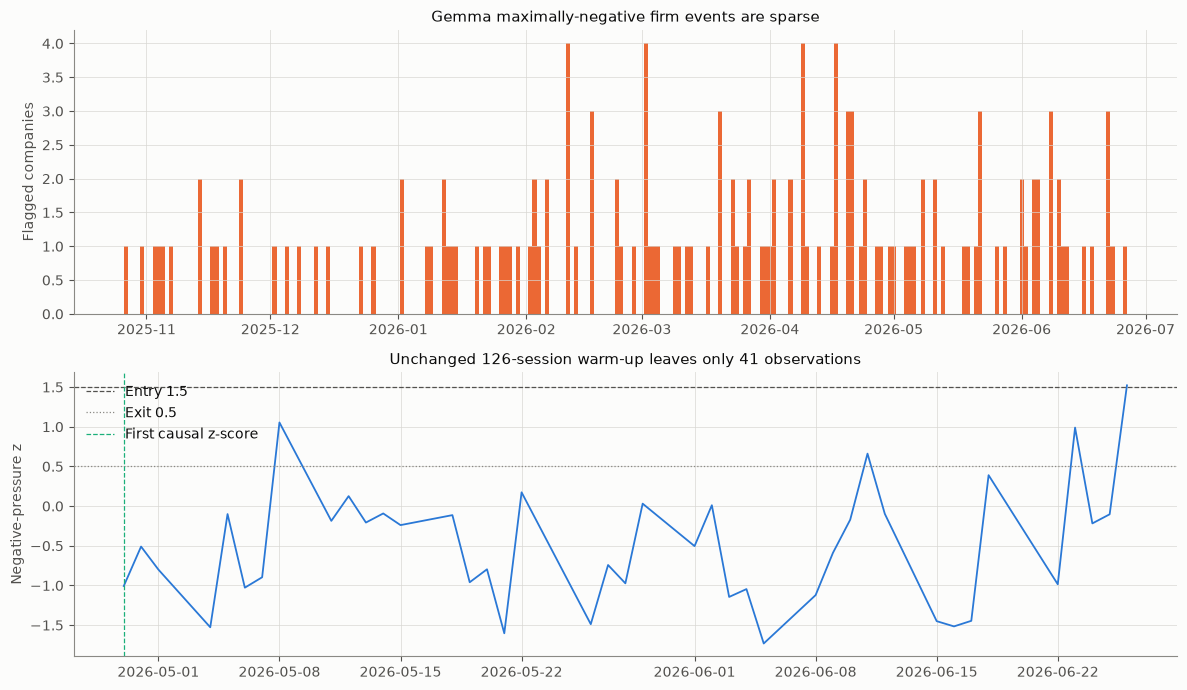

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
daily_flag_count = firm_flag.sum(axis=1)
axes[0].bar(daily_flag_count.index, daily_flag_count, color=CATEGORICAL[1], width=1.0)
axes[0].set_ylabel("Flagged companies")
axes[0].set_title("Gemma maximally-negative firm events are sparse")

axes[1].plot(
    pressure["session_date"],
    pressure["negative_pressure_z"],
    color=CATEGORICAL[0],
    linewidth=1.3,
)
axes[1].axhline(1.5, color=INK["reference"], linestyle="--", linewidth=0.9, label="Entry 1.5")
axes[1].axhline(0.5, color=INK["muted"], linestyle=":", linewidth=0.9, label="Exit 0.5")
axes[1].axvline(
    market_eligible["session_date"].min(),
    color=CATEGORICAL[2],
    linestyle="--",
    linewidth=0.9,
    label="First causal z-score",
)
axes[1].set_ylabel("Negative-pressure z")
axes[1].set_title("Unchanged 126-session warm-up leaves only 41 observations")
axes[1].legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "signal_activity_and_warmup.png", dpi=170, bbox_inches="tight")
plt.show()

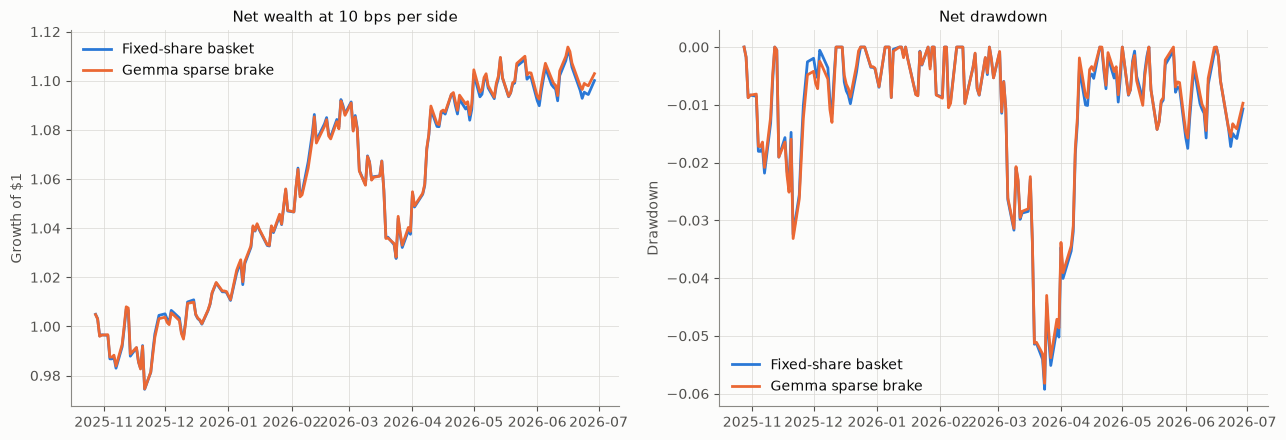

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for arm, label, colour in (
    ("baseline", "Fixed-share basket", CATEGORICAL[0]),
    ("firm_brake", "Gemma sparse brake", CATEGORICAL[1]),
):
    daily = daily_paths["full"][arm]
    equity = (1.0 + daily["net_return"]).cumprod()
    drawdown = equity / np.maximum.accumulate(np.r_[1.0, equity])[-len(equity):] - 1.0
    axes[0].plot(daily["return_end_date"], equity, label=label, color=colour)
    axes[1].plot(daily["return_end_date"], drawdown, label=label, color=colour)
axes[0].set_title("Net wealth at 10 bps per side")
axes[0].set_ylabel("Growth of $1")
axes[1].set_title("Net drawdown")
axes[1].set_ylabel("Drawdown")
axes[0].legend(loc="best")
axes[1].legend(loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "firm_brake_equity_and_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

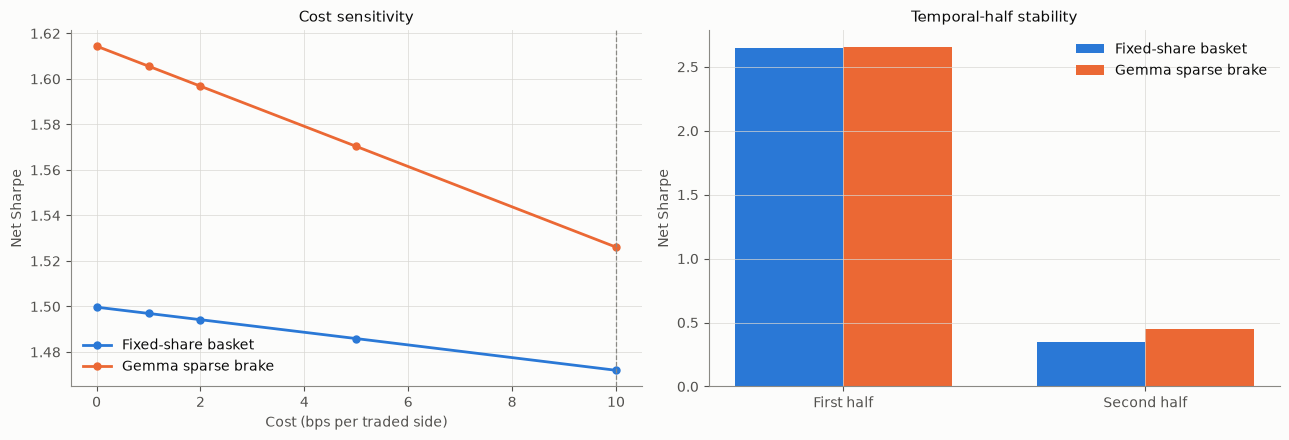

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for arm, label, colour in (
    ("baseline", "Fixed-share basket", CATEGORICAL[0]),
    ("firm_brake", "Gemma sparse brake", CATEGORICAL[1]),
):
    line = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[0].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        label=label,
        color=colour,
    )
half_plot = results.loc[results["period"].isin(["first_half", "second_half"])]
pivot = half_plot.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["first_half", "second_half"]
)
x = np.arange(len(pivot))
axes[1].bar(x - 0.18, pivot["baseline"], 0.36, label="Fixed-share basket", color=CATEGORICAL[0])
axes[1].bar(x + 0.18, pivot["firm_brake"], 0.36, label="Gemma sparse brake", color=CATEGORICAL[1])
axes[0].axvline(COST_BPS, color=INK["muted"], linestyle="--", linewidth=0.9)
axes[0].set_xlabel("Cost (bps per traded side)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Cost sensitivity")
axes[0].legend(loc="best")
axes[1].set_xticks(x, ["First half", "Second half"])
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Temporal-half stability")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_and_temporal_stability.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [11]:
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
coverage.to_csv(OUTPUT_DIR / "coverage_audit.csv", index=False)
signal_audit.to_csv(OUTPUT_DIR / "signal_audit.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
pressure.to_parquet(OUTPUT_DIR / "daily_market_pressure.parquet", index=False)
for period, arms in daily_paths.items():
    for arm, daily in arms.items():
        daily.to_parquet(OUTPUT_DIR / f"{period}_{arm}_daily.parquet", index=False)
for arm, daily in market_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"market_finite_z_{arm}_daily.parquet", index=False)

if alpha_gate:
    verdict = "The sparse Gemma firm brake passes the exploratory alpha gate."
elif useful_risk_gate:
    verdict = "The sparse Gemma firm brake passes the useful-risk gate, not the alpha gate."
else:
    verdict = "The sparse Gemma firm brake passes neither the alpha nor useful-risk gate."
market_verdict = (
    "The unchanged market hysteresis is feasible."
    if market_feasible
    else "The unchanged market hysteresis is not evaluable: its causal warm-up leaves too few sessions and triggers."
)

manifest = {
    "notebook": "26_lseg_gemma_sparse_risk_brakes",
    "analysis_status": "iterative_retrospective_non_pooled_lseg_robustness_2026-08-05",
    "selection_disclosure": (
        "Notebook 13 already opened these returns and selected Gemma strongest_event as the best gross arm; "
        "this follow-up is hypothesis-generating, not a fresh holdout."
    ),
    "population": {
        "companies": len(symbols),
        "firm_open_rows": len(gemma),
        "entry_sessions": len(gemma_sessions),
        "first_entry_session": str(gemma_sessions.min().date()),
        "last_entry_session": str(gemma_sessions.max().date()),
    },
    "timing": {
        "information_buffer_minutes": 15,
        "entry": "first XNYS open at least 15 minutes after first headline timestamp",
        "return": "split-adjusted non-dividend-adjusted open-to-next-open",
    },
    "design": {
        "base": "fixed-share 44-company basket, initially equal-dollar",
        "firm_brake": "one interval at 25% fixed shares when Gemma strongest_event == -1.0",
        "market_hysteresis": "headline-weighted negative share; prior 252/min126 z; entry 1.5; exit 0.5; 25% exposure",
        "cost_bps_per_traded_side": COST_BPS,
        "cost_grid": list(COST_GRID),
        "cash_return": 0.0,
        "final_liquidation": True,
        "bootstrap": {
            "block_length_sessions": BLOCK_LENGTH,
            "replications": BOOTSTRAP_REPLICATIONS,
            "seed": SEED,
        },
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "signal_audit": json.loads(signal_audit.to_json(orient="records"))[0],
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(inference.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "verdict": verdict,
    "market_verdict": market_verdict,
    "limitations": [
        "retrospective eight-month snapshot whose returns were already opened in Notebook 13",
        "strongest_event was selected for follow-up after its Notebook 13 gross result",
        "44 large US companies are not a diversified market index",
        "price returns are split-adjusted but not dividend-adjusted",
        "cash return is fixed at zero",
        "the market-level rule has only 41 causal z-score sessions and one risk-off trigger",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

display(
    Markdown(
        f"""### Decision

**{verdict}** {market_verdict}

- Fixed-share basket gross/net Sharpe: **{base['sharpe_gross']:.3f} / {base['sharpe_net']:.3f}**;
  net return **{base['total_return_net']:.2%}**; drawdown **{base['max_drawdown']:.2%}**.
- Sparse Gemma brake gross/net Sharpe: **{firm['sharpe_gross']:.3f} / {firm['sharpe_net']:.3f}**;
  net return **{firm['total_return_net']:.2%}**; drawdown **{firm['max_drawdown']:.2%}**.
- Paired net improvement: **{return_test['mean_difference'] * 10_000:.3f} bps/day**,
  95% block-bootstrap CI **[{return_test['ci_low'] * 10_000:.3f}, {return_test['ci_high'] * 10_000:.3f}]**,
  p = **{return_test['p_two_sided']:.3f}**.
- The firm brake affects **{int(firm_flag.sum().sum()):,} / {firm_flag.size:,}** firm-sessions
  and has **{int(firm_entries.sum().sum()):,}** distinct entries. Its gross incremental
  break-even cost is **{incremental_breakeven:.2f} bps per traded side**.
- The unchanged market rule has **{len(market_sessions)}** finite-z sessions and
  **{int(market_eligible['risk_off'].sum())}** risk-off session, below the frozen
  **{MIN_MARKET_Z_SESSIONS}/{MIN_MARKET_RISK_OFF}** feasibility minimum.

This notebook keeps Gemma/LSEG in the strategy programme, but its inference is
bounded by the short, previously opened Reuters sample.
"""
    )
)

### Decision

**The sparse Gemma firm brake passes neither the alpha nor useful-risk gate.** The unchanged market hysteresis is not evaluable: its causal warm-up leaves too few sessions and triggers.

- Fixed-share basket gross/net Sharpe: **1.500 / 1.472**;
  net return **10.01%**; drawdown **-5.93%**.
- Sparse Gemma brake gross/net Sharpe: **1.614 / 1.526**;
  net return **10.29%**; drawdown **-5.82%**.
- Paired net improvement: **0.148 bps/day**,
  95% block-bootstrap CI **[-0.405, 0.678]**,
  p = **0.588**.
- The firm brake affects **143 / 7,348** firm-sessions
  and has **118** distinct entries. Its gross incremental
  break-even cost is **15.74 bps per traded side**.
- The unchanged market rule has **41** finite-z sessions and
  **1** risk-off session, below the frozen
  **60/5** feasibility minimum.

This notebook keeps Gemma/LSEG in the strategy programme, but its inference is
bounded by the short, previously opened Reuters sample.
